# CAMELS-DE version 1.1.0

This notebook creates CAMELS-DE version 1.1.0 from version 1.0.0

## Changes

### Major
* LSTM benchmark results are now based on a LSTM with 10 ensemble members, changing the median NSE in the testing period from 0.83 to 0.85
    * The columns `discharge_spec_sim_lstm` and `discharge_vol_sim_lstm` in `timeseries_simulated` are now based on the median values of the 10 ensemble members
        * If you are interested in the individual ensemble members, please contact the authors (adding all ensemble members would have significantly increased the file size)
    * The column `NSE_lstm` in `CAMELS_DE_simulation_benchmark.csv` is now calculated from the median simulations of the 10 ensemble members
    * `model_parameters/LSTM/CAMELS_DE_epochs_training_lstm.zip` now contains the epochs of the 10 ensemble members 

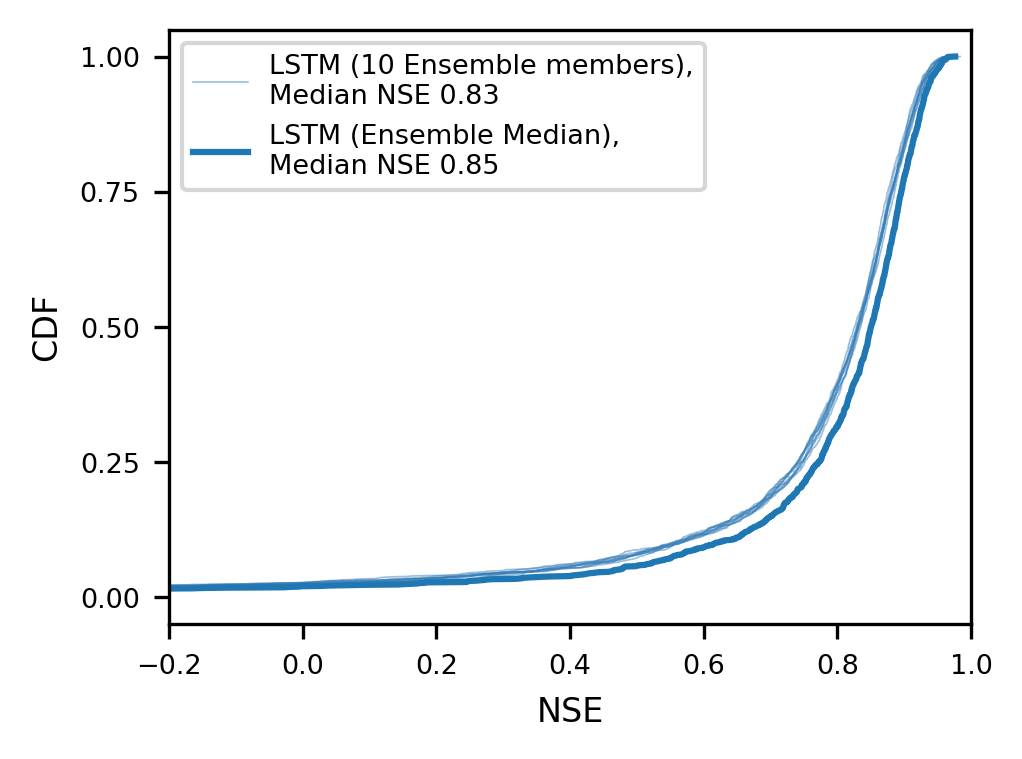

### Minor & Bugfixes
* `training_perc_complete` was calculated from 2001 - 2020, corrected to 2000 - 2020
* bug in climate indices calculation fixed (thank you to Bastian Klein from BfG for reporting)
* Bayern: removed blank space after gauge and water body name and removed water body name from some gauge names, where it was included as "[gauge_name]_[water_body_name]", e.g. "Würzburg_Main" -> "Würzburg", water body name is now only included in the `water_body_name` column
* NRW: corrected some wrong river names in topographic attributes
* Sachsen: added `gauge_elevation_metadata` information to topographic attributes

In [ ]:
from pathlib import Path
from glob import glob
import pickle
import os
import shutil

import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from hy2dl.aux_functions.functions_evaluation import nse

In [2]:
# path to the CAMELS_DE v1.0.0
camels_de_v1_path = Path("/home/alexd/datasets/CAMELS_DE_v1_0_0/")

# path to store update CAMELS_DE v1.1.0
camels_de_v1_1_path = Path("./CAMELS_DE_v1_1_0/")
camels_de_v1_1_path.mkdir(exist_ok=True)

## Copy the files from CAMELS-DE v1.0.0 to CAMELS-DE v1.1.0

We mostly use the timeseries, attributes and geopackages / shapefiles from CAMELS-DE v1.0.0 and update the files that have changed.  
Files that are not copied:
* `CAMELS_DE_topographic_attributes.csv`
* `CAMELS_DE_climatic_attributes.csv`
* `CAMELS_DE_simulation_benchmark.csv` (updated with new LSTM ensemble results)
* `timeseries_simulated/CAMELS_DE_discharge_sim_*.csv` (updated with new LSTM ensemble results)
* `model_parameters/LSTM/CAMELS_DE_epochs_training_lstm.zip` (updated with new LSTM ensemble results)

In [3]:
# attributes
attribute_files = camels_de_v1_path.glob("CAMELS_DE*attributes.csv")

# filter those attributes that we do not want to copy
attribute_files = [f for f in attribute_files if f.name not in ["CAMELS_DE_topographic_attributes.csv", "CAMELS_DE_climatic_attributes.csv"]]

# copy the attributes to the new path
for file in attribute_files:
    shutil.copy(file, camels_de_v1_1_path / file.name)

# copy the geopackages / shapefiles folder
shutil.copytree(camels_de_v1_path / "CAMELS_DE_catchment_boundaries", camels_de_v1_1_path / "CAMELS_DE_catchment_boundaries", dirs_exist_ok=True)

# copy the timeseries folder
shutil.copytree(camels_de_v1_path / "timeseries", camels_de_v1_1_path / "timeseries", dirs_exist_ok=True)

# copy the HBV model parameters
shutil.copytree(camels_de_v1_path / "model_parameters" / "HBV", camels_de_v1_1_path / "model_parameters" / "HBV", dirs_exist_ok=True)

PosixPath('CAMELS_DE_v1_1_0/model_parameters/HBV')

### Simulation benchmark

Merge ensemble data (10 different random seeds / initializations) into a single benchmark by taking the median simulated discharge for each time step.

In [4]:
# Read the results generated using Hy2DL
path_results_LSTM = sorted(glob("./ensemble_runs_full_period/ensemble_LSTM_CAMELS_DE_forward_seed_*"))

print(f"Found LSTM ensemble results for random seeds: [{', '.join([p.split('_')[-1] for p in path_results_LSTM])}]")

# Read information produced by ensemble of LSTMs and store it in dictionary of dataframes
lstm_results_full = {}
for i, ensemble_member in tqdm(enumerate(path_results_LSTM)):
    with open(ensemble_member + "/test_results.pickle", "rb") as f:
        info_lstm = pickle.load(f)
    # Iterate over each basin
    for basin in info_lstm.keys():
        df = info_lstm[basin]
        y_sim = df["y_sim"].round(2)
        if i == 0: # If this is the first ensemble member, initialize the DataFrame with y_obs and y_sim
            y_obs = df["y_obs"].round(2)
            lstm_results_full[basin] = pd.DataFrame(data={"y_obs": y_obs, f"y_sim_ens_{i+1}": y_sim}, index=y_obs.index)
        else: # For subsequent ensemble members, add y_sim as a new column
            lstm_results_full[basin][f"y_sim_ens_{i+1}"] = y_sim

# Calculate the median of the simulated values and add it as a new column
for basin in lstm_results_full.keys():
    # Select only the y_sim columns
    y_sim_columns = [col for col in lstm_results_full[basin].columns if col.startswith("y_sim_ens_")]
    lstm_results_full[basin]["y_sim"] = lstm_results_full[basin][y_sim_columns].median(axis=1)

Found LSTM ensemble results for random seeds: [110, 120, 130, 140, 170, 200, 220, 240, 250, 42]


0it [00:00, ?it/s]

10it [00:10,  1.09s/it]


In [5]:
# simulation periods
training = ["1970-10-01", "1999-12-31"]
validation = ["1965-10-01", "1970-09-30"]
testing = ["2000-01-01", "2020-12-31"]  # updated testing period

Save timeseries, here we use the full period, not only the testing period and flag the training, validation and testing period.

In [6]:
if not (camels_de_v1_1_path / "timeseries_simulated").exists():
    os.makedirs(camels_de_v1_1_path / "timeseries_simulated")

df_topo = pd.read_csv(camels_de_v1_path / f"CAMELS_DE_topographic_attributes.csv")

for id in tqdm(lstm_results_full.keys()):
    df_camels = pd.read_csv(camels_de_v1_path / "timeseries_simulated" / f"CAMELS_DE_discharge_sim_{id}.csv", parse_dates=["date"])
    
    # get area of the basin in km^2
    area = df_topo.loc[df_topo["gauge_id"] == id, "area"].values[0] * 1e6  # convert from km^2 to m^2

    # set column simulation_period to "testing" for the testing period (2000-01-01 to 2020-12-31)
    df_camels.loc[(df_camels["date"] >= "2000-01-01") & (df_camels["date"] <= "2020-12-31"), "simulation_period"] = "testing"

    # set discharge_spec_sim_lstm to the median of the ensemble members
    df_camels["discharge_spec_sim_lstm"] = lstm_results_full[id]["y_sim"].values

    # calculate discharge_vol_sim_lstm from discharge_spec_sim_lstm
    df_camels["discharge_vol_sim_lstm"] = df_camels["discharge_spec_sim_lstm"] * area / (24 * 3600) / 1000  # mm/day to m3/s

    # round to 2 decimal places
    df_camels["discharge_vol_sim_lstm"] = df_camels["discharge_vol_sim_lstm"].round(2)
    df_camels["discharge_spec_sim_lstm"] = df_camels["discharge_spec_sim_lstm"].round(2)

    # save the DataFrame to csv
    df_camels.to_csv(camels_de_v1_1_path / "timeseries_simulated" / f"CAMELS_DE_discharge_sim_{id}.csv", index=False)

100%|██████████| 1582/1582 [02:31<00:00, 10.44it/s]


Calculate LSTM ensemble NSE for the testing period and save it in the `CAMELS_DE_simulation_benchmark.csv` file.  
Also recalculate `testing_perc_complete` from 2000 - 2020, not 2001 - 2020.

In [7]:
df_benchmark = pd.read_csv(camels_de_v1_path / "CAMELS_DE_simulation_benchmark.csv")

for id in tqdm(lstm_results_full.keys()):
    df = pd.read_csv(camels_de_v1_1_path / "timeseries_simulated" / f"CAMELS_DE_discharge_sim_{id}.csv", parse_dates=["date"], index_col="date")

    # count number with discharge_spec that are not NaN for each period
    training_count = df.loc[training[0]:training[1], "discharge_spec_obs"].count()
    validation_count = df.loc[validation[0]:validation[1], "discharge_spec_obs"].count()
    testing_count = df.loc[testing[0]:testing[1], "discharge_spec_obs"].count()

    # get ratio of stations with discharge_spec data for each period
    training_perc_complete = training_count / len(df.loc[training[0]:training[1], "discharge_spec_obs"]) * 100 # in percent
    validation_perc_complete = validation_count / len(df.loc[validation[0]:validation[1], "discharge_spec_obs"]) * 100 # in percent
    testing_perc_complete = testing_count / len(df.loc[testing[0]:testing[1], "discharge_spec_obs"]) * 100 # in percent

    # round to 2 decimal places
    training_perc_complete = round(training_perc_complete, 2)
    validation_perc_complete = round(validation_perc_complete, 2)
    testing_perc_complete = round(testing_perc_complete, 2)

    # set the values in the benchmark DataFrame
    df_benchmark.loc[df_benchmark["gauge_id"] == id, "training_perc_complete"] = training_perc_complete
    df_benchmark.loc[df_benchmark["gauge_id"] == id, "validation_perc_complete"] = validation_perc_complete
    df_benchmark.loc[df_benchmark["gauge_id"] == id, "testing_perc_complete"] = testing_perc_complete

    # filter the DataFrame to only include the testing period
    df_testing = df.loc[(df["simulation_period"] == "testing")].copy()

    # calculate NSE for the testing period
    nse_lstm = round(nse(df_results={id: df_testing.rename(columns={"discharge_spec_sim_lstm": "y_sim", "discharge_spec_obs": "y_obs"})}, average=False)[0], 3)
    nse_hbv = round(nse(df_results={id: df_testing.rename(columns={"discharge_spec_sim_hbv": "y_sim", "discharge_spec_obs": "y_obs"})}, average=False)[0], 3)
    
    # add the NSE values to the benchmark DataFrame
    df_benchmark.loc[df_benchmark["gauge_id"] == id, "NSE_lstm"] = nse_lstm
    df_benchmark.loc[df_benchmark["gauge_id"] == id, "NSE_hbv"] = nse_hbv    

# save
df_benchmark.to_csv(camels_de_v1_1_path / "CAMELS_DE_simulation_benchmark.csv", index=False)

100%|██████████| 1582/1582 [00:40<00:00, 38.67it/s]


Save the LSTM ensemble epochs in the `model_parameters/LSTM/CAMELS_DE_epochs_training_lstm.zip` file.

In [8]:
epoch_save_path = camels_de_v1_1_path / "model_parameters" / "LSTM"
if not epoch_save_path.exists():
    os.makedirs(epoch_save_path)

# Save the epochs directly in a zip file without intermediate folders
import zipfile
with zipfile.ZipFile(epoch_save_path / "ensemble_CAMELS_DE_epochs_training_lstm.zip", 'w') as zipf:
    for ensemble_member in path_results_LSTM:
        seed = ensemble_member.split("_")[-1]
        epochs = sorted(glob(f"{ensemble_member}/epoch*"))
        for epoch in epochs:
            zipf.write(epoch, arcname=f"ensemble_LSTM_CAMELS_DE_seed_{seed}/{Path(epoch).name}")

### Climatic attributes

There was a critical bug in the calculation of the climatic attributes `low_prec_dur` and `high_prec_dur` (values accumulated from catchment to catchment, instead of being reset for each catchment). We fix this bug here.

In [9]:
climatic_attributes = pd.read_csv(camels_de_v1_path / "CAMELS_DE_climatic_attributes.csv")

gauge_ids = climatic_attributes["gauge_id"].values

In [10]:
def filter_complete_hydro_years(df, tolerance=0.05):
    """
    Helper function to filter a DataFrame to only include complete hydrological 
    years (October - September). A hydrological year is considered complete if 
    it has less than the specified tolerance of missing values.

    """
    # if date is not in index, set it as index
    if 'date' in df.columns:
        df = df.set_index('date')

    # convert the index to datetime if it is not already
    if not isinstance(df.index, pd.DatetimeIndex): 
        df.index = pd.to_datetime(df.index)

    # make the dataframe start at the beginning of the hydrological year, i.e. 01.10. of the previous year
    min_year = df.index.year.min()
    df = df.reindex(pd.date_range(start=f"{min_year-1}-10-01", end=df.index.max(), freq='D'))

    # make the dataframe end at the end of the hydrological year, i.e. 30.09. of the next year
    max_year = df.index.year.max()
    df = df.reindex(pd.date_range(start=df.index.min(), end=f"{max_year+1}-09-30", freq='D'))

    # Calculate the number of missing values per hydrological year for 'discharge_vol_obs' column
    df['hydro_year'] = df.index.year
    df.loc[df.index.month >= 10, 'hydro_year'] += 1
    missing_values_per_year = df['discharge_vol_obs'].groupby(df['hydro_year']).apply(lambda x: x.isna().mean())

    # Filter the DataFrame to only include years with less than the tolerance of missing values
    df_filtered = df[df['hydro_year'].isin(missing_values_per_year[missing_values_per_year <= tolerance].index)]

    # Drop the 'hydro_year' column
    df_filtered = df_filtered.drop(columns='hydro_year')

    return df_filtered

low_prec_dur

In [11]:
df_results = pd.DataFrame(index=gauge_ids)

for id in gauge_ids:
    # initialize variables to keep track of high precipitation event -> this was outside the loop and is fixed now!
    low_precip_streaks = []
    current_streak = 0

    # read camels de hydromet timeseries data
    df = pd.read_csv(camels_de_v1_path / f"timeseries/CAMELS_DE_hydromet_timeseries_{id}.csv")

    # filter complete hydrological years
    df = filter_complete_hydro_years(df)
    
    # iterate over the DataFrame's rows
    for precip in df["precipitation_mean"]:
        if precip < 1:
            # if the day's precipitation is higher 5 times mean precipitation, increment the current streak
            current_streak += 1
        elif current_streak > 0:
            # if the day's precipitation is not high and there's a current streak, add it to the list of all streaks and reset it
            low_precip_streaks.append(current_streak)
            current_streak = 0

    # if there's a current streak at the end of the DataFrame, add it to the list of all streaks
    if current_streak > 0:
        low_precip_streaks.append(current_streak)

    # calculate the average streak length for the station
    average_streak_length = sum(low_precip_streaks) / len(low_precip_streaks) if low_precip_streaks else 0

    # add to results
    df_results.loc[id, "low_prec_dur"] = round(average_streak_length, 2)

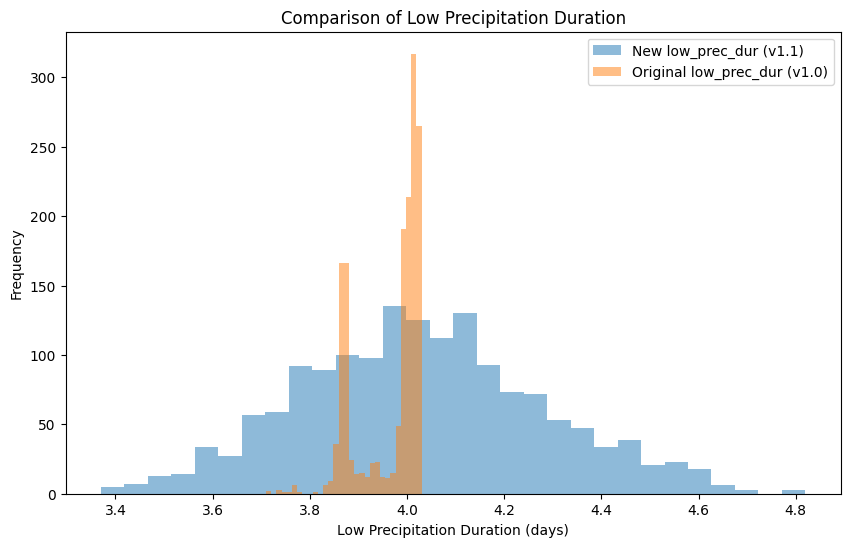

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df_results["low_prec_dur"], bins=30, alpha=0.5, label='New low_prec_dur (v1.1)')
plt.hist(climatic_attributes["low_prec_dur"], bins=30, alpha=0.5, label='Original low_prec_dur (v1.0)')
plt.xlabel('Low Precipitation Duration (days)')
plt.ylabel('Frequency')
plt.title('Comparison of Low Precipitation Duration')
plt.legend()
plt.show() 

high_prec_dur

In [13]:
for id in gauge_ids:
    # initialize variables to keep track of high precipitation event
    high_precip_streaks = []
    current_streak = 0

    # read camels de hydromet timeseries data
    df = pd.read_csv(camels_de_v1_path / f"timeseries/CAMELS_DE_hydromet_timeseries_{id}.csv")

    # filter complete hydrological years
    df = filter_complete_hydro_years(df)
    
    # mean precipitation
    p_mean = df["precipitation_mean"].mean()

    # iterate over the DataFrame's rows
    for precip in df["precipitation_mean"]:
        if precip >= 5 * p_mean:
            # if the day's precipitation is higher 5 times mean precipitation, increment the current streak
            current_streak += 1
        elif current_streak > 0:
            # if the day's precipitation is not high and there's a current streak, add it to the list of all streaks and reset it
            high_precip_streaks.append(current_streak)
            current_streak = 0

    # if there's a current streak at the end of the DataFrame, add it to the list of all streaks
    if current_streak > 0:
        high_precip_streaks.append(current_streak)

    # calculate the average streak length for the station
    average_streak_length = sum(high_precip_streaks) / len(high_precip_streaks) if high_precip_streaks else 0

    # add to results
    df_results.loc[id, "high_prec_dur"] = round(average_streak_length, 2)

df_results.head()

,low_prec_dur,high_prec_dur
DE110000,3.71,1.19
DE110010,3.72,1.20
DE110020,3.78,1.17
DE110030,3.76,1.15
DE110040,3.77,1.18


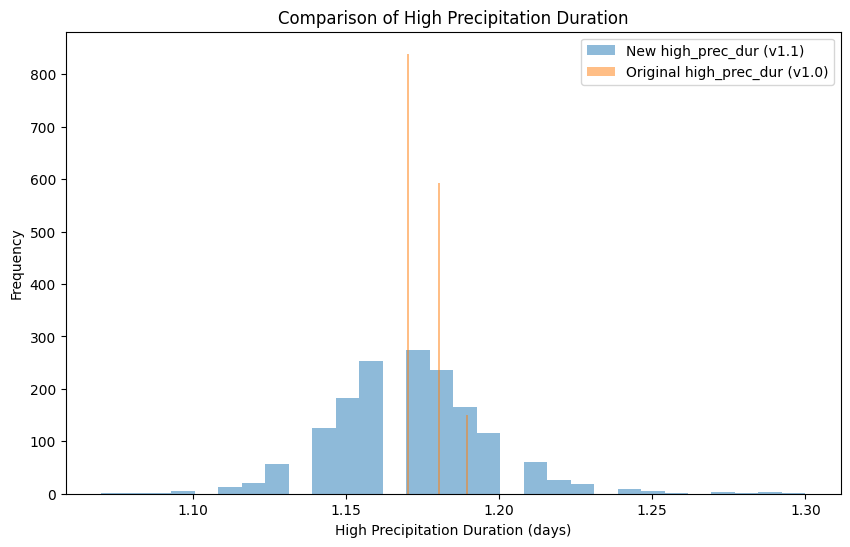

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df_results["high_prec_dur"], bins=30, alpha=0.5, label='New high_prec_dur (v1.1)')
plt.hist(climatic_attributes["high_prec_dur"], bins=30, alpha=0.5, label='Original high_prec_dur (v1.0)')
plt.xlabel('High Precipitation Duration (days)')
plt.ylabel('Frequency')
plt.title('Comparison of High Precipitation Duration')
plt.legend()
plt.show() 

In [15]:
# add to climatic attributes (overwrite existing values)
climatic_attributes.set_index("gauge_id", inplace=True)
climatic_attributes.update(df_results)
climatic_attributes.reset_index(inplace=True)

climatic_attributes.to_csv(camels_de_v1_1_path / "CAMELS_DE_climatic_attributes.csv", index=False)

### Topographic Attributes

In [16]:
topographic_attributes = pd.read_csv(camels_de_v1_path / "CAMELS_DE_topographic_attributes.csv")

##### Bayern: remove blank space after gauge and waterbody name

In [17]:
mask = topographic_attributes["federal_state"] == "Bayern"

print(topographic_attributes.loc[mask, ["gauge_name", "water_body_name"]].head(2).to_string(index=False))
print("\n")

# Remove trailing blank space in 'gauge_name' and both leading/trailing in 'water_body_name' for Bayern
topographic_attributes.loc[mask, "gauge_name"] = topographic_attributes.loc[mask, "gauge_name"].str.rstrip()
topographic_attributes.loc[mask, "water_body_name"] = topographic_attributes.loc[mask, "water_body_name"].str.strip()

print(topographic_attributes.loc[mask, ["gauge_name", "water_body_name"]].head(2).to_string(index=False))

 gauge_name    water_body_name
    Winkel          Starzlach 
Gunzesried   Gunzesrieder Ach 


gauge_name  water_body_name
    Winkel        Starzlach
Gunzesried Gunzesrieder Ach


#### Bayern: remove water body name from some gauge names

e.g. "Würzburg_Main" -> "Würzburg", water body name is now only included in the `water_body_name` column, as it already was for most of the gauges in Bayern.

In [18]:
mask = topographic_attributes["federal_state"] == "Bayern"

def clean_gauge_name(row):
    gauge_name = row["gauge_name"]
    water_body_name = row["water_body_name"]
    if "_" in gauge_name:
        gauge_part, river_part = gauge_name.rsplit("_", 1)

        if river_part == water_body_name:
            return gauge_part
        else:
            print(f"Warning: Gauge name '{gauge_name}' does not match water body name '{water_body_name}'. Keeping original gauge name.")
    return gauge_name

topographic_attributes.loc[mask, "gauge_name"] = topographic_attributes.loc[mask].apply(clean_gauge_name, axis=1)

#### NRW: correct some wrong river names in topographic attributes

wrong river names (by provider_id):
- `2721459000100`	'Ferndorf' -> is actually `Ferndorfbach`
- `2721490000100`	'Ferndorf' -> is actually `Ferndorfbach`
- `2762510000300`   'Möhne' -> is actually `Bormelsbach`
- `2783250000100`	'Strothe' -> is actually `Thune`
- `4566900000100`	'Diestel' -> is actually `Diestelbach`


In [19]:
nrw_corrections = {
    "2721459000100": ("Ferndorf", "Ferndorfbach"),
    "2721490000100": ("Ferndorf", "Ferndorfbach"),
    "2762510000300": ("Möhne", "Bormelsbach"),
    "2783250000100": ("Strothe", "Thune"),
    "4566900000100": ("Diestel", "Diestelbach")
}

# remove entries that are not in topographic attributes
for provider_id, (old_name, new_name) in nrw_corrections.items():
    if provider_id in topographic_attributes["provider_id"].values:
        topographic_attributes.loc[
            topographic_attributes["provider_id"] == provider_id, "water_body_name"
        ] = new_name
        print(f"Updated {provider_id}: {old_name} -> {new_name}")
    else:
        print(f"Provider ID {provider_id} not found in topographic attributes.")

Updated 2721459000100: Ferndorf -> Ferndorfbach
Updated 2721490000100: Ferndorf -> Ferndorfbach
Updated 2762510000300: Möhne -> Bormelsbach
Updated 2783250000100: Strothe -> Thune
Updated 4566900000100: Diestel -> Diestelbach


#### Sachsen: add `gauge_elevation_metadata` information to topographic attributes

In [20]:
gauge_elevation_sachsen = pd.read_csv("gauge_elevation_sachsen.csv") # gauge_id and gauge_elev_metadata columns

# Create a mapping from gauge_id to gauge_elev_metadata
sachsen_elev_map = dict(zip(gauge_elevation_sachsen["gauge_id"], gauge_elevation_sachsen["gauge_elev_metadata"]))

# Update only Sachsen rows
sachsen_mask = topographic_attributes["federal_state"] == "Sachsen"
topographic_attributes.loc[sachsen_mask, "gauge_elev_metadata"] = topographic_attributes.loc[sachsen_mask, "gauge_id"].map(sachsen_elev_map).combine_first(topographic_attributes.loc[sachsen_mask, "gauge_elev_metadata"])

In [21]:
# save the updated topographic attributes
topographic_attributes.to_csv(camels_de_v1_1_path / "CAMELS_DE_topographic_attributes.csv", index=False)